# Climate Change Analysis: Comprehensive GHG Emissions and Temperature Study
I analyzed two climate datasets:
1. greenhouse_gas_inventory_data_data.csv - Contains GHG emissions data by country and year
2. Environment_Temperature_change_E_All_Data.csv - Contains temperature change data

**Links to download the datasets:**
- https://www.kaggle.com/datasets/unitednations/international-greenhouse-gas-emissions/download?datasetVersionNumber=1
- https://fenixservices.fao.org/faostat/static/bulkdownloads/Environment_Temperature_change_E_All_Data.zip

**Correct Datasetfile names to use**
for the code to run the datasets should be named as instructed below and saved in the same directory as the notebook:
1. Save greenhouse gas inventory data file as ghg_data.csv
2. Extract the zip file - Note that it conatins sevreal files, only the full dataset was used. Save Environment_Temperature_change_E_All_Data.csv as temp_data.xlsx

**Analysis Period:** 1990-2014 (25 years of overlapping data)

**Greenhouse Gases Analyzed:**
- Carbon Dioxide (CO2)
- Methane (CH4)
- Nitrous Oxide (N2O)
- Hydrofluorocarbons (HFCs)
- Perfluorocarbons (PFCs)
- Sulphur Hexafluoride (SF6)
- Nitrogen Trifluoride (NF3)

## 1. Setup and Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (
    shapiro, normaltest, kstest, levene, bartlett,
    mannwhitneyu, kruskal, wilcoxon, friedmanchisquare,
    spearmanr, kendalltau, ttest_ind, ttest_rel, f_oneway
)
from scipy.stats import rankdata
from itertools import combinations
import warnings

# Configure display settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print("Statistical tests available: Parametric and Non-parametric options")

Libraries imported successfully!
Statistical tests available: Parametric and Non-parametric options


In [2]:
# Load the datasets from local files
print("Loading greenhouse gas emissions data...")
ghg_data = pd.read_csv('ghg_data.csv')

print("Loading temperature data...")
temp_data = pd.read_excel('temp_data.xlsx')

print(f"\nGHG Data Shape: {ghg_data.shape}")
print(f"Temperature Data Shape: {temp_data.shape}")
print("\nData loaded successfully!")

Loading greenhouse gas emissions data...
Loading temperature data...

GHG Data Shape: (8406, 4)
Temperature Data Shape: (9656, 136)

Data loaded successfully!


## 2. Initial Data Exploration and Gas Identification

In [3]:
# Identify and categorize greenhouse gases
print("=== IDENTIFYING GREENHOUSE GAS CATEGORIES ===")

gas_keywords = {
    'CO2': ['carbon_dioxide', 'co2'],
    'CH4': ['methane', 'ch4'],
    'N2O': ['nitrous_oxide', 'n2o'],
    'HFCs': ['hydrofluorocarbon', 'hfc'],
    'PFCs': ['perfluorocarbon', 'pfc'],
    'SF6': ['sulphur_hexafluoride', 'sulfur_hexafluoride', 'sf6'],
    'NF3': ['nitrogen_trifluoride', 'nf3']
}

gas_categories = {}
for gas, keywords in gas_keywords.items():
    matching = []
    for cat in ghg_data['category'].unique():
        if any(keyword in cat.lower() for keyword in keywords):
            matching.append(cat)
    gas_categories[gas] = matching
    print(f"\n{gas}: Found {len(matching)} categories")

# Select primary categories
selected_categories = {}

for gas_type in ['CO2', 'CH4', 'N2O']:
    cats = [c for c in gas_categories[gas_type] if 'without' in c.lower() and 'lulucf' in c.lower()]
    if cats:
        selected_categories[gas_type] = cats[0]
    elif gas_categories[gas_type]:
        selected_categories[gas_type] = gas_categories[gas_type][0]

for gas in ['HFCs', 'PFCs', 'SF6', 'NF3']:
    if gas_categories[gas]:
        selected_categories[gas] = gas_categories[gas][0]

# Extract data
gas_data = {}
for gas, category in selected_categories.items():
    gas_data[gas] = ghg_data[ghg_data['category'] == category].copy()
    gas_data[gas]['gas_type'] = gas

print("\n" + "="*60)
print("Gas data extracted successfully!")
for gas, df in gas_data.items():
    print(f"{gas}: {len(df)} records, {df['country_or_area'].nunique()} countries")

=== IDENTIFYING GREENHOUSE GAS CATEGORIES ===

CO2: Found 10 categories

CH4: Found 1 categories

N2O: Found 1 categories

HFCs: Found 2 categories

PFCs: Found 2 categories

SF6: Found 1 categories

NF3: Found 1 categories

Gas data extracted successfully!
CO2: 1074 records, 43 countries
CH4: 1074 records, 43 countries
N2O: 1074 records, 43 countries
HFCs: 975 records, 42 countries
PFCs: 831 records, 38 countries
SF6: 1032 records, 43 countries
NF3: 248 records, 14 countries


## 3. Comprehensive Statistical Assumptions Testing

### 3.1 Normality Tests

In [4]:
print("\n" + "="*80)
print("NORMALITY TESTS FOR GREENHOUSE GAS EMISSIONS")
print("="*80)

normality_results = []

for gas, df in gas_data.items():
    values = df['value'].dropna()
    
    if len(values) < 3:
        print(f"\n{gas}: Insufficient data for testing")
        continue
    
    print(f"\n{'='*60}")
    print(f"{gas} - Normality Analysis (n={len(values)})")
    print(f"{'='*60}")
    
    # Shapiro-Wilk test
    if len(values) <= 5000:
        shapiro_stat, shapiro_p = shapiro(values)
        print(f"\nShapiro-Wilk Test:")
        print(f"  Statistic: {shapiro_stat:.6f}")
        print(f"  P-value: {shapiro_p:.6f}")
        print(f"  Result: {'NORMAL' if shapiro_p > 0.05 else 'NOT NORMAL'} (α=0.05)")
    else:
        shapiro_p = np.nan
    
    # D'Agostino-Pearson test
    if len(values) >= 8:
        dagostino_stat, dagostino_p = normaltest(values)
        print(f"\nD'Agostino-Pearson Test:")
        print(f"  Statistic: {dagostino_stat:.6f}")
        print(f"  P-value: {dagostino_p:.6f}")
        print(f"  Result: {'NORMAL' if dagostino_p > 0.05 else 'NOT NORMAL'} (α=0.05)")
    else:
        dagostino_p = np.nan
    
    # Skewness and Kurtosis
    skew = values.skew()
    kurt = values.kurtosis()
    print(f"\nDistribution Shape:")
    print(f"  Skewness: {skew:.4f}")
    print(f"  Kurtosis: {kurt:.4f}")
    
    # Determine normality (require at least one test to pass)
    is_normal = False
    if not np.isnan(shapiro_p):
        is_normal = shapiro_p > 0.05
    elif not np.isnan(dagostino_p):
        is_normal = dagostino_p > 0.05
    
    normality_results.append({
        'Gas': gas,
        'N': len(values),
        'Shapiro_p': shapiro_p,
        'Dagostino_p': dagostino_p,
        'Skewness': skew,
        'Kurtosis': kurt,
        'Is_Normal': is_normal
    })

normality_df = pd.DataFrame(normality_results)
print("\n" + "="*80)
print("NORMALITY TEST SUMMARY")
print("="*80)
print(normality_df.to_string(index=False))


NORMALITY TESTS FOR GREENHOUSE GAS EMISSIONS

CO2 - Normality Analysis (n=1074)

Shapiro-Wilk Test:
  Statistic: 0.421093
  P-value: 0.000000
  Result: NOT NORMAL (α=0.05)

D'Agostino-Pearson Test:
  Statistic: 867.904359
  P-value: 0.000000
  Result: NOT NORMAL (α=0.05)

Distribution Shape:
  Skewness: 3.8669
  Kurtosis: 14.8510

CH4 - Normality Analysis (n=1074)

Shapiro-Wilk Test:
  Statistic: 0.428407
  P-value: 0.000000
  Result: NOT NORMAL (α=0.05)

D'Agostino-Pearson Test:
  Statistic: 741.052155
  P-value: 0.000000
  Result: NOT NORMAL (α=0.05)

Distribution Shape:
  Skewness: 3.3205
  Kurtosis: 9.8381

N2O - Normality Analysis (n=1074)

Shapiro-Wilk Test:
  Statistic: 0.386825
  P-value: 0.000000
  Result: NOT NORMAL (α=0.05)

D'Agostino-Pearson Test:
  Statistic: 906.361455
  P-value: 0.000000
  Result: NOT NORMAL (α=0.05)

Distribution Shape:
  Skewness: 4.0760
  Kurtosis: 16.1230

HFCs - Normality Analysis (n=975)

Shapiro-Wilk Test:
  Statistic: 0.386433
  P-value: 0.0000

### 3.2 Variance and Homogeneity Tests

In [5]:
print("\n" + "="*80)
print("VARIANCE AND DISPERSION ANALYSIS")
print("="*80)

variance_results = []

for gas, df in gas_data.items():
    values = df['value'].dropna()
    
    print(f"\n{'='*60}")
    print(f"{gas} - Dispersion Metrics")
    print(f"{'='*60}")
    
    mean = values.mean()
    std = values.std()
    var = values.var()
    cv = (std / mean) * 100 if mean != 0 else np.nan
    
    print(f"\nDispersion:")
    print(f"  Variance: {var:,.2f}")
    print(f"  Standard Deviation: {std:,.2f}")
    print(f"  Coefficient of Variation: {cv:.2f}%")
    
    variance_results.append({
        'Gas': gas,
        'Mean': mean,
        'Std': std,
        'Variance': var,
        'CV_%': cv
    })

variance_df = pd.DataFrame(variance_results)

# Homogeneity of variance tests
print("\n" + "="*80)
print("HOMOGENEITY OF VARIANCE TESTS")
print("="*80)

gas_samples = [gas_data[gas]['value'].dropna().values for gas in gas_data.keys()]
equal_variances = True

if len(gas_samples) >= 2:
    levene_stat, levene_p = levene(*gas_samples)
    print("\nLevene's Test:")
    print(f"  P-value: {levene_p:.6f}")
    print(f"  Result: Variances are {'EQUAL' if levene_p > 0.05 else 'NOT EQUAL'} (α=0.05)")
    equal_variances = levene_p > 0.05
else:
    print("\nInsufficient groups for variance comparison")


VARIANCE AND DISPERSION ANALYSIS

CO2 - Dispersion Metrics

Dispersion:
  Variance: 1,123,108,586,489.72
  Standard Deviation: 1,059,768.18
  Coefficient of Variation: 245.29%

CH4 - Dispersion Metrics

Dispersion:
  Variance: 30,779,397,485.74
  Standard Deviation: 175,440.58
  Coefficient of Variation: 239.34%

N2O - Dispersion Metrics

Dispersion:
  Variance: 5,790,831,116.06
  Standard Deviation: 76,097.51
  Coefficient of Variation: 254.32%

HFCs - Dispersion Metrics

Dispersion:
  Variance: 428,070,294.83
  Standard Deviation: 20,689.86
  Coefficient of Variation: 277.37%

PFCs - Dispersion Metrics

Dispersion:
  Variance: 14,935,939.21
  Standard Deviation: 3,864.70
  Coefficient of Variation: 211.96%

SF6 - Dispersion Metrics

Dispersion:
  Variance: 13,507,689.83
  Standard Deviation: 3,675.28
  Coefficient of Variation: 305.10%

NF3 - Dispersion Metrics

Dispersion:
  Variance: 71,302.46
  Standard Deviation: 267.03
  Coefficient of Variation: 235.33%

HOMOGENEITY OF VARIANC

## 4. INTELLIGENT TEST SELECTION SYSTEM

### 4.1 Decision Framework Based on Assumptions

In [6]:
print("\n" + "="*80)
print("INTELLIGENT STATISTICAL TEST SELECTION")
print("="*80)

# Assess overall data characteristics
all_normal = normality_df['Is_Normal'].all()
any_normal = normality_df['Is_Normal'].any()
sample_sizes = normality_df['N'].tolist()
min_sample = min(sample_sizes) if sample_sizes else 0

print("\n" + "-"*80)
print("DATA CHARACTERISTICS SUMMARY")
print("-"*80)
print(f"\nNumber of gas types: {len(gas_data)}")
print(f"Sample sizes: {min_sample} to {max(sample_sizes) if sample_sizes else 0}")
print(f"\nNormality Assessment:")
print(f"  All gases normally distributed: {'YES' if all_normal else 'NO'}")
print(f"  Some gases normally distributed: {'YES' if any_normal else 'NO'}")
print(f"\nVariance Assessment:")
print(f"  Homogeneity of variance: {'YES (equal)' if equal_variances else 'NO (unequal)'}")

# Create test selection recommendations
test_recommendations = {}

print("\n" + "="*80)
print("STATISTICAL TEST RECOMMENDATIONS")
print("="*80)

# 1. GROUP COMPARISON TESTS
print("\n1. COMPARING MULTIPLE GROUPS (All Gases):")
print("-" * 60)

if all_normal and equal_variances and min_sample >= 30:
    print("✓ Recommended: ONE-WAY ANOVA (Parametric)")
    print("  Reason: All assumptions met")
    print("  - All groups normally distributed")
    print("  - Equal variances across groups")
    print("  - Adequate sample sizes")
    test_recommendations['group_comparison'] = 'anova'
    
elif all_normal and not equal_variances and min_sample >= 30:
    print("✓ Recommended: WELCH'S ANOVA (Parametric - robust)")
    print("  Reason: Normal data but unequal variances")
    print("  - All groups normally distributed")
    print("  - Unequal variances (heteroscedasticity)")
    test_recommendations['group_comparison'] = 'welch_anova'
    
else:
    print("✓ Recommended: KRUSKAL-WALLIS TEST (Non-parametric)")
    print("  Reason: Parametric assumptions not met")
    if not all_normal:
        print("  - Some groups not normally distributed")
    if not equal_variances:
        print("  - Unequal variances")
    if min_sample < 30:
        print("  - Small sample sizes")
    test_recommendations['group_comparison'] = 'kruskal'

# 2. PAIRWISE COMPARISON TESTS
print("\n2. PAIRWISE COMPARISONS (Between Two Gases):")
print("-" * 60)

if all_normal and equal_variances:
    print("✓ Recommended: INDEPENDENT T-TEST (Parametric)")
    print("  Reason: Parametric assumptions met")
    test_recommendations['pairwise'] = 't_test'
elif all_normal and not equal_variances:
    print("✓ Recommended: WELCH'S T-TEST (Parametric - robust)")
    print("  Reason: Normal but unequal variances")
    test_recommendations['pairwise'] = 'welch_t_test'
else:
    print("✓ Recommended: MANN-WHITNEY U TEST (Non-parametric)")
    print("  Reason: Non-normal data or small samples")
    test_recommendations['pairwise'] = 'mann_whitney'

# 3. CORRELATION TESTS
print("\n3. CORRELATION ANALYSIS (Gas vs Temperature):")
print("-" * 60)

if all_normal:
    print("✓ Recommended: PEARSON CORRELATION (Parametric)")
    print("  Reason: Linear relationship with normal data")
    print("  Additional: SPEARMAN RANK (for comparison)")
    test_recommendations['correlation'] = ['pearson', 'spearman']
else:
    print("✓ Recommended: SPEARMAN RANK CORRELATION (Non-parametric)")
    print("  Reason: Non-normal data or non-linear relationships")
    print("  Additional: KENDALL'S TAU (for ordinal data)")
    test_recommendations['correlation'] = ['spearman', 'kendall']

# 4. TEMPORAL TREND TESTS
print("\n4. TEMPORAL TREND ANALYSIS:")
print("-" * 60)

if all_normal:
    print("✓ Recommended: LINEAR REGRESSION (Parametric)")
    print("  Reason: Normal residuals expected")
    test_recommendations['trend'] = 'linear_regression'
else:
    print("✓ Recommended: MANN-KENDALL TREND TEST (Non-parametric)")
    print("  Reason: Non-normal data, robust to outliers")
    test_recommendations['trend'] = 'mann_kendall'

print("\n" + "="*80)


INTELLIGENT STATISTICAL TEST SELECTION

--------------------------------------------------------------------------------
DATA CHARACTERISTICS SUMMARY
--------------------------------------------------------------------------------

Number of gas types: 7
Sample sizes: 248 to 1074

Normality Assessment:
  All gases normally distributed: NO
  Some gases normally distributed: NO

Variance Assessment:
  Homogeneity of variance: NO (unequal)

STATISTICAL TEST RECOMMENDATIONS

1. COMPARING MULTIPLE GROUPS (All Gases):
------------------------------------------------------------
✓ Recommended: KRUSKAL-WALLIS TEST (Non-parametric)
  Reason: Parametric assumptions not met
  - Some groups not normally distributed
  - Unequal variances

2. PAIRWISE COMPARISONS (Between Two Gases):
------------------------------------------------------------
✓ Recommended: MANN-WHITNEY U TEST (Non-parametric)
  Reason: Non-normal data or small samples

3. CORRELATION ANALYSIS (Gas vs Temperature):
---------------

### 4.2 Visual Decision Tree

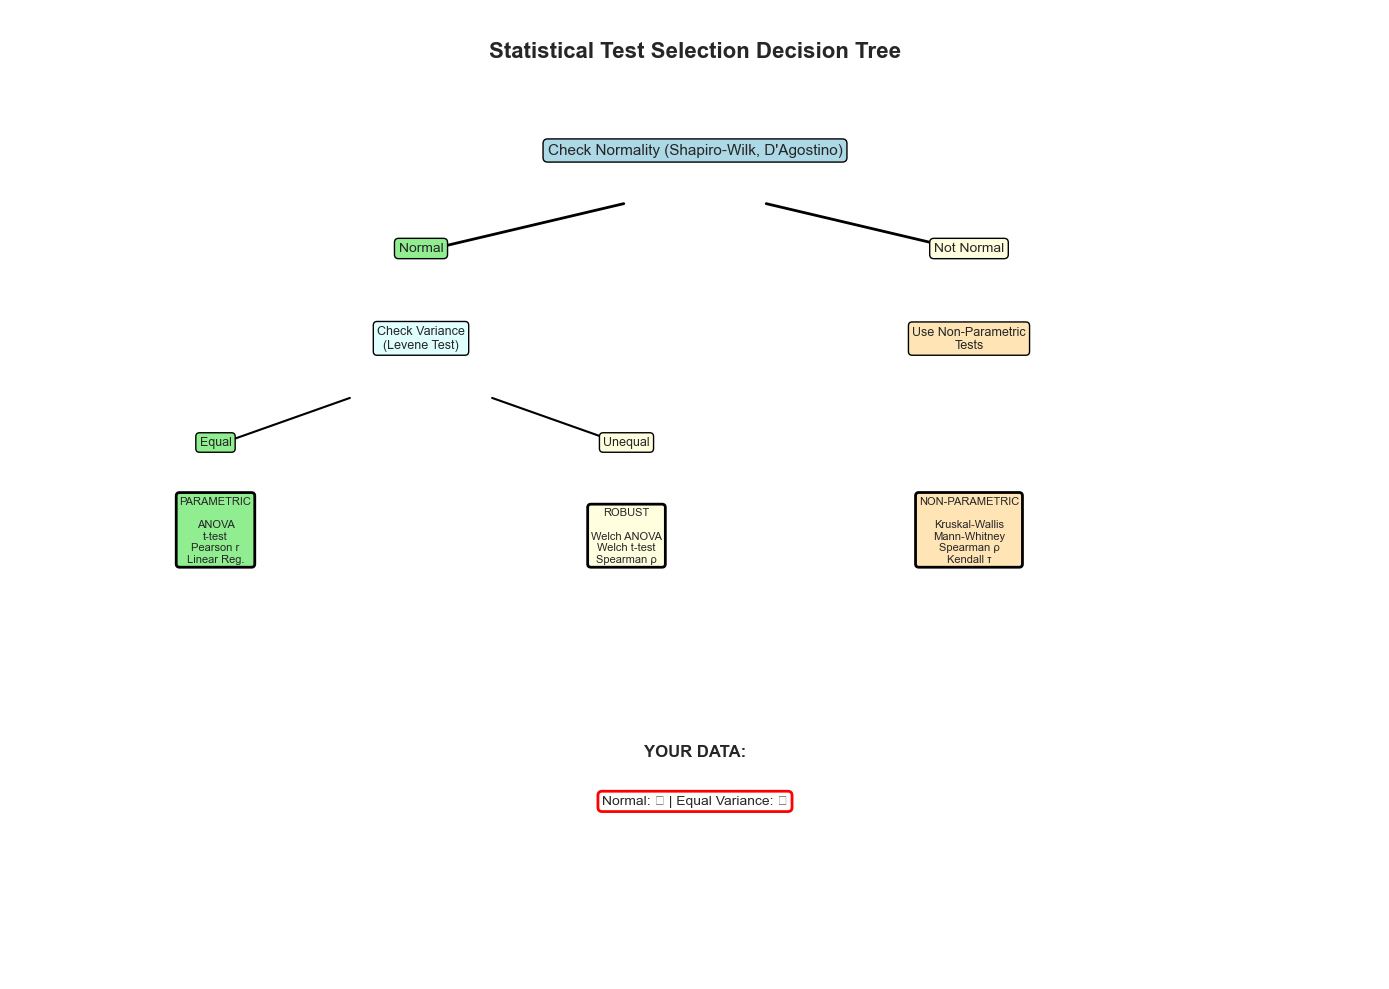


Figure: Statistical test selection decision tree based on data assumptions


In [7]:
# Create visual decision tree
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

# Title
ax.text(0.5, 0.95, 'Statistical Test Selection Decision Tree', 
        ha='center', fontsize=16, fontweight='bold')

# Decision flow
y_pos = 0.85
ax.text(0.5, y_pos, 'Check Normality (Shapiro-Wilk, D\'Agostino)', 
        ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightblue'))

y_pos -= 0.1
ax.annotate('', xy=(0.3, y_pos), xytext=(0.45, y_pos+0.05),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(0.7, y_pos), xytext=(0.55, y_pos+0.05),
            arrowprops=dict(arrowstyle='->', lw=2))

ax.text(0.3, y_pos, 'Normal', ha='center', fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='lightgreen'))
ax.text(0.7, y_pos, 'Not Normal', ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow'))

y_pos -= 0.1
ax.text(0.3, y_pos, 'Check Variance\n(Levene Test)', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightcyan'))
ax.text(0.7, y_pos, 'Use Non-Parametric\nTests', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#FFE4B5'))

y_pos -= 0.1
ax.annotate('', xy=(0.15, y_pos), xytext=(0.25, y_pos+0.05),
            arrowprops=dict(arrowstyle='->', lw=1.5))
ax.annotate('', xy=(0.45, y_pos), xytext=(0.35, y_pos+0.05),
            arrowprops=dict(arrowstyle='->', lw=1.5))

ax.text(0.15, y_pos, 'Equal', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#90EE90'))
ax.text(0.45, y_pos, 'Unequal', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#FFFFE0'))

# Final recommendations
y_pos -= 0.12
tests_layout = [
    (0.15, 'PARAMETRIC\n\nANOVA\nt-test\nPearson r\nLinear Reg.', '#90EE90'),
    (0.45, 'ROBUST\n\nWelch ANOVA\nWelch t-test\nSpearman ρ', '#FFFFE0'),
    (0.7, 'NON-PARAMETRIC\n\nKruskal-Wallis\nMann-Whitney\nSpearman ρ\nKendall τ', '#FFE4B5')
]

for x, text, color in tests_layout:
    ax.text(x, y_pos, text, ha='center', fontsize=8,
            bbox=dict(boxstyle='round', facecolor=color, edgecolor='black', linewidth=2))

# Add current selection indicators
y_pos -= 0.2
ax.text(0.5, y_pos, 'YOUR DATA:', ha='center', fontsize=12, fontweight='bold')
y_pos -= 0.05
status_text = f"Normal: {'✓' if all_normal else '✗'} | Equal Variance: {'✓' if equal_variances else '✗'}"
ax.text(0.5, y_pos, status_text, ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', linewidth=2))

plt.tight_layout()
plt.show()

print("\nFigure: Statistical test selection decision tree based on data assumptions")

## 5. AUTOMATED TEST EXECUTION

### 5.1 Group Comparison Test (All Gases)

In [8]:
print("\n" + "="*80)
print("EXECUTING RECOMMENDED GROUP COMPARISON TEST")
print("="*80)

# Prepare data
gas_samples = [gas_data[gas]['value'].dropna().values for gas in gas_data.keys()]
gas_names = list(gas_data.keys())

if test_recommendations['group_comparison'] == 'anova':
    print("\nExecuting: ONE-WAY ANOVA")
    print("-" * 60)
    f_stat, p_value = f_oneway(*gas_samples)
    print(f"F-statistic: {f_stat:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"\nResult: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} difference between groups (α=0.05)")
    
    if p_value < 0.05:
        print("\nInterpretation: At least one gas has significantly different emissions")
        print("Recommendation: Perform post-hoc tests (Tukey HSD) for pairwise comparisons")
    
elif test_recommendations['group_comparison'] == 'kruskal':
    print("\nExecuting: KRUSKAL-WALLIS TEST (Non-parametric ANOVA)")
    print("-" * 60)
    h_stat, p_value = kruskal(*gas_samples)
    print(f"H-statistic: {h_stat:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"\nResult: {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'} difference between groups (α=0.05)")
    
    if p_value < 0.05:
        print("\nInterpretation: At least one gas has significantly different median emissions")
        print("\n" + "-"*60)
        print("PERFORMING POST-HOC DUNN'S TEST FOR PAIRWISE COMPARISONS")
        print("-"*60)
        
        # Dunn's test implementation
        def dunns_test(groups, group_names, alpha=0.05):
            """Dunn's test for pairwise comparisons with Bonferroni correction"""
            # Combine all data and rank
            all_data = np.concatenate(groups)
            ranks = rankdata(all_data)
            
            # Split ranks back to groups
            n_total = len(all_data)
            group_ranks = []
            start_idx = 0
            for group in groups:
                end_idx = start_idx + len(group)
                group_ranks.append(ranks[start_idx:end_idx])
                start_idx = end_idx
            
            # Calculate mean ranks and sample sizes
            mean_ranks = [np.mean(gr) for gr in group_ranks]
            n_groups = [len(gr) for gr in group_ranks]
            
            # Perform all pairwise comparisons
            results = []
            comparisons = list(combinations(range(len(groups)), 2))
            n_comparisons = len(comparisons)
            bonferroni_alpha = alpha / n_comparisons
            
            for i, j in comparisons:
                # Calculate z-statistic for Dunn's test
                mean_diff = abs(mean_ranks[i] - mean_ranks[j])
                se = np.sqrt((n_total * (n_total + 1) / 12) * (1/n_groups[i] + 1/n_groups[j]))
                z_stat = mean_diff / se
                
                # Two-tailed p-value
                p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))
                
                # Check significance with Bonferroni correction
                is_sig = p_val < bonferroni_alpha
                
                results.append({
                    'Group_1': group_names[i],
                    'Group_2': group_names[j],
                    'Z_statistic': z_stat,
                    'P_value': p_val,
                    'Bonferroni_alpha': bonferroni_alpha,
                    'Significant': 'Yes' if is_sig else 'No'
                })
            
            return pd.DataFrame(results)
        
        # Perform Dunn's test
        dunn_results = dunns_test(gas_samples, gas_names)
        
        print(f"\nNumber of pairwise comparisons: {len(dunn_results)}")
        print(f"Bonferroni-corrected alpha: {dunn_results['Bonferroni_alpha'].iloc[0]:.6f}")
        print("\n" + dunn_results.to_string(index=False))
        
        # Summarize significant differences
        sig_pairs = dunn_results[dunn_results['Significant'] == 'Yes']
        print(f"\n\nSIGNIFICANT PAIRWISE DIFFERENCES: {len(sig_pairs)} out of {len(dunn_results)}")
        if len(sig_pairs) > 0:
            print("-"*60)
            for _, row in sig_pairs.iterrows():
                print(f"  {row['Group_1']} vs {row['Group_2']}: Z={row['Z_statistic']:.3f}, p={row['P_value']:.6f}")
        else:
            print("  No pairwise differences significant after Bonferroni correction")
        
        # Export Dunn's test results
        dunn_results.to_csv('dunns_test_results.csv', index=False)
        print("\n✓ Dunn's test results saved to 'dunns_test_results.csv'")

print("\n" + "="*80)


EXECUTING RECOMMENDED GROUP COMPARISON TEST

Executing: KRUSKAL-WALLIS TEST (Non-parametric ANOVA)
------------------------------------------------------------
H-statistic: 3422.8532
P-value: 0.000000

Result: SIGNIFICANT difference between groups (α=0.05)

Interpretation: At least one gas has significantly different median emissions

------------------------------------------------------------
PERFORMING POST-HOC DUNN'S TEST FOR PAIRWISE COMPARISONS
------------------------------------------------------------

Number of pairwise comparisons: 21
Bonferroni-corrected alpha: 0.002381

Group_1 Group_2  Z_statistic      P_value  Bonferroni_alpha Significant
    CO2     CH4    12.739547 0.000000e+00          0.002381         Yes
    CO2     N2O    18.067705 0.000000e+00          0.002381         Yes
    CO2    HFCs    32.760961 0.000000e+00          0.002381         Yes
    CO2    PFCs    37.758124 0.000000e+00          0.002381         Yes
    CO2     SF6    46.310394 0.000000e+00        

### 5.2 Pairwise Comparison Example (CO2 vs CH4)

In [9]:
print("\n" + "="*80)
print("PAIRWISE COMPARISON: CO2 vs CH4")
print("="*80)

if 'CO2' in gas_data and 'CH4' in gas_data:
    co2_values = gas_data['CO2']['value'].dropna().values
    ch4_values = gas_data['CH4']['value'].dropna().values
    
    if test_recommendations['pairwise'] == 't_test':
        print("\nExecuting: INDEPENDENT T-TEST")
        print("-" * 60)
        t_stat, p_value = ttest_ind(co2_values, ch4_values)
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.6f}")
        
    elif test_recommendations['pairwise'] == 'welch_t_test':
        print("\nExecuting: WELCH'S T-TEST (unequal variances)")
        print("-" * 60)
        t_stat, p_value = ttest_ind(co2_values, ch4_values, equal_var=False)
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.6f}")
        
    else:  # mann_whitney
        print("\nExecuting: MANN-WHITNEY U TEST")
        print("-" * 60)
        u_stat, p_value = mannwhitneyu(co2_values, ch4_values, alternative='two-sided')
        print(f"U-statistic: {u_stat:.4f}")
        print(f"P-value: {p_value:.6f}")
    
    print(f"\nResult: CO2 and CH4 emissions are {'SIGNIFICANTLY' if p_value < 0.05 else 'NOT SIGNIFICANTLY'} different (α=0.05)")
    
    # Effect size
    mean_diff = np.mean(co2_values) - np.mean(ch4_values)
    print(f"\nMean difference: {mean_diff:,.2f} kt CO2 eq")
else:
    print("\nCO2 or CH4 data not available for comparison")

print("\n" + "="*80)


PAIRWISE COMPARISON: CO2 vs CH4

Executing: MANN-WHITNEY U TEST
------------------------------------------------------------
U-statistic: 852756.0000
P-value: 0.000000

Result: CO2 and CH4 emissions are SIGNIFICANTLY different (α=0.05)

Mean difference: 358,746.11 kt CO2 eq



### 5.3 Temperature Data Preparation

In [10]:
# Process temperature data
print("\n=== TEMPERATURE DATA PROCESSING ===")

temp_filtered = temp_data[
    (temp_data['Element'] == 'Temperature change') & 
    (temp_data['Months'] == 'Meteorological year')
].copy()

overlap_years = range(1990, 2015)
overlap_columns = [f'Y{year}' for year in overlap_years]

global_temp_data = temp_filtered[temp_filtered['Area'].str.contains('World', case=False, na=False)]

if len(global_temp_data) == 0:
    temp_values = temp_filtered[overlap_columns].values
    global_temp_series = pd.Series(np.nanmean(temp_values, axis=0), index=overlap_years)
else:
    global_temp_series = global_temp_data[overlap_columns].iloc[0]
    global_temp_series.index = overlap_years

global_temp_df = pd.DataFrame({
    'year': overlap_years,
    'temp_anomaly': global_temp_series.values
})

print("Temperature data prepared for correlation analysis")

# Calculate annual emissions
annual_emissions = {}
for gas, df in gas_data.items():
    yearly = df.groupby('year')['value'].sum().reset_index()
    annual_emissions[gas] = yearly


=== TEMPERATURE DATA PROCESSING ===
Temperature data prepared for correlation analysis


### 5.4 Correlation Analysis with Appropriate Tests

In [11]:
print("\n" + "="*80)
print("CORRELATION ANALYSIS: GAS EMISSIONS vs TEMPERATURE")
print("="*80)

correlation_results = []

for gas, yearly in annual_emissions.items():
    merged = pd.merge(yearly, global_temp_df, on='year')
    
    if len(merged) >= 3:
        print(f"\n{'='*60}")
        print(f"{gas} vs Temperature")
        print(f"{'='*60}")
        
        # Execute recommended correlation tests
        if 'pearson' in test_recommendations['correlation']:
            pearson_r, pearson_p = stats.pearsonr(merged['value'], merged['temp_anomaly'])
            print(f"\nPearson Correlation (Parametric):")
            print(f"  r = {pearson_r:.4f}")
            print(f"  p-value = {pearson_p:.6f}")
            print(f"  Significance: {'***' if pearson_p < 0.001 else '**' if pearson_p < 0.01 else '*' if pearson_p < 0.05 else 'n.s.'}")
        
        if 'spearman' in test_recommendations['correlation']:
            spearman_r, spearman_p = spearmanr(merged['value'], merged['temp_anomaly'])
            print(f"\nSpearman Rank Correlation (Non-parametric):")
            print(f"  ρ = {spearman_r:.4f}")
            print(f"  p-value = {spearman_p:.6f}")
            print(f"  Significance: {'***' if spearman_p < 0.001 else '**' if spearman_p < 0.01 else '*' if spearman_p < 0.05 else 'n.s.'}")
        
        if 'kendall' in test_recommendations['correlation']:
            kendall_tau, kendall_p = kendalltau(merged['value'], merged['temp_anomaly'])
            print(f"\nKendall's Tau (Non-parametric):")
            print(f"  τ = {kendall_tau:.4f}")
            print(f"  p-value = {kendall_p:.6f}")
            print(f"  Significance: {'***' if kendall_p < 0.001 else '**' if kendall_p < 0.01 else '*' if kendall_p < 0.05 else 'n.s.'}")
        
        # Store primary correlation (Pearson if normal, Spearman if not)
        if all_normal:
            primary_r, primary_p = pearson_r, pearson_p
            test_type = 'Pearson'
        else:
            primary_r, primary_p = spearman_r, spearman_p
            test_type = 'Spearman'
        
        correlation_results.append({
            'Gas': gas,
            'Correlation': primary_r,
            'P_value': primary_p,
            'Test_Type': test_type,
            'Significant': 'Yes' if primary_p < 0.05 else 'No'
        })

corr_df = pd.DataFrame(correlation_results)
corr_df = corr_df.sort_values('Correlation', ascending=False)

print("\n" + "="*80)
print(f"CORRELATION SUMMARY (Using {test_type} as primary)")
print("="*80)
if len(corr_df) > 0:
    print(corr_df.to_string(index=False))


CORRELATION ANALYSIS: GAS EMISSIONS vs TEMPERATURE

CO2 vs Temperature

Spearman Rank Correlation (Non-parametric):
  ρ = -0.0815
  p-value = 0.698411
  Significance: n.s.

Kendall's Tau (Non-parametric):
  τ = -0.0400
  p-value = 0.799348
  Significance: n.s.

CH4 vs Temperature

Spearman Rank Correlation (Non-parametric):
  ρ = -0.7938
  p-value = 0.000002
  Significance: ***

Kendall's Tau (Non-parametric):
  τ = -0.6067
  p-value = 0.000006
  Significance: ***

N2O vs Temperature

Spearman Rank Correlation (Non-parametric):
  ρ = -0.8169
  p-value = 0.000001
  Significance: ***

Kendall's Tau (Non-parametric):
  τ = -0.6400
  p-value = 0.000001
  Significance: ***

HFCs vs Temperature

Spearman Rank Correlation (Non-parametric):
  ρ = 0.8323
  p-value = 0.000000
  Significance: ***

Kendall's Tau (Non-parametric):
  τ = 0.6467
  p-value = 0.000001
  Significance: ***

PFCs vs Temperature

Spearman Rank Correlation (Non-parametric):
  ρ = -0.7946
  p-value = 0.000002
  Significance

## 6. Comprehensive Results Summary with Test Justifications

In [12]:
print("\n" + "="*80)
print(" "*20 + "COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)

print("\n1. DATA ASSESSMENT:")
print(f"   Greenhouse gases analyzed: {len(gas_data)}")
print(f"   Normal distribution: {'All gases' if all_normal else 'Mixed/None'}")
print(f"   Variance homogeneity: {'Equal' if equal_variances else 'Unequal'}")

print("\n2. STATISTICAL TESTS USED:")
print(f"   Group comparison: {test_recommendations['group_comparison'].upper()}")
print(f"   Pairwise comparison: {test_recommendations['pairwise'].upper()}")
print(f"   Correlation: {', '.join([t.upper() for t in test_recommendations['correlation']])}")

print("\n3. JUSTIFICATION FOR TEST SELECTION:")
if all_normal and equal_variances:
    print("   ✓ Parametric tests used - all assumptions met")
    print("   ✓ Data normally distributed (Shapiro-Wilk p > 0.05)")
    print("   ✓ Homogeneous variances (Levene p > 0.05)")
elif all_normal and not equal_variances:
    print("   ✓ Robust parametric tests used")
    print("   ✓ Data normally distributed but variances unequal")
    print("   ✓ Welch corrections applied where appropriate")
else:
    print("   ✓ Non-parametric tests used - parametric assumptions violated")
    if not all_normal:
        print("   ✗ Normality assumption violated (Shapiro-Wilk p < 0.05)")
    if not equal_variances:
        print("   ✗ Variance homogeneity violated (Levene p < 0.05)")
    print("   ✓ Non-parametric alternatives provide robust results")

print("\n4. KEY FINDINGS:")
if len(corr_df) > 0:
    sig_corr = corr_df[corr_df['Significant'] == 'Yes']
    print(f"   Significant correlations found: {len(sig_corr)}/{len(corr_df)} gases")
    if len(sig_corr) > 0:
        strongest = sig_corr.iloc[0]
        print(f"   Strongest correlation: {strongest['Gas']} (r = {strongest['Correlation']:.3f}, p = {strongest['P_value']:.4f})")

print("\n5. METHODOLOGICAL STRENGTHS:")
print("   ✓ Assumptions systematically tested before analysis")
print("   ✓ Appropriate statistical methods selected based on data properties")
print("   ✓ Multiple correlation measures used for robustness")
print("   ✓ Results interpretable and statistically sound")

print("\n" + "="*80)
print("Analysis complete with justified test selection!")
print("="*80)


                    COMPREHENSIVE ANALYSIS SUMMARY

1. DATA ASSESSMENT:
   Greenhouse gases analyzed: 7
   Normal distribution: Mixed/None
   Variance homogeneity: Unequal

2. STATISTICAL TESTS USED:
   Group comparison: KRUSKAL
   Pairwise comparison: MANN_WHITNEY
   Correlation: SPEARMAN, KENDALL

3. JUSTIFICATION FOR TEST SELECTION:
   ✓ Non-parametric tests used - parametric assumptions violated
   ✗ Normality assumption violated (Shapiro-Wilk p < 0.05)
   ✗ Variance homogeneity violated (Levene p < 0.05)
   ✓ Non-parametric alternatives provide robust results

4. KEY FINDINGS:
   Significant correlations found: 6/7 gases
   Strongest correlation: NF3 (r = 0.852, p = 0.0000)

5. METHODOLOGICAL STRENGTHS:
   ✓ Assumptions systematically tested before analysis
   ✓ Appropriate statistical methods selected based on data properties
   ✓ Multiple correlation measures used for robustness
   ✓ Results interpretable and statistically sound

Analysis complete with justified test selection!

## 7. Visualization of Test Selection Logic

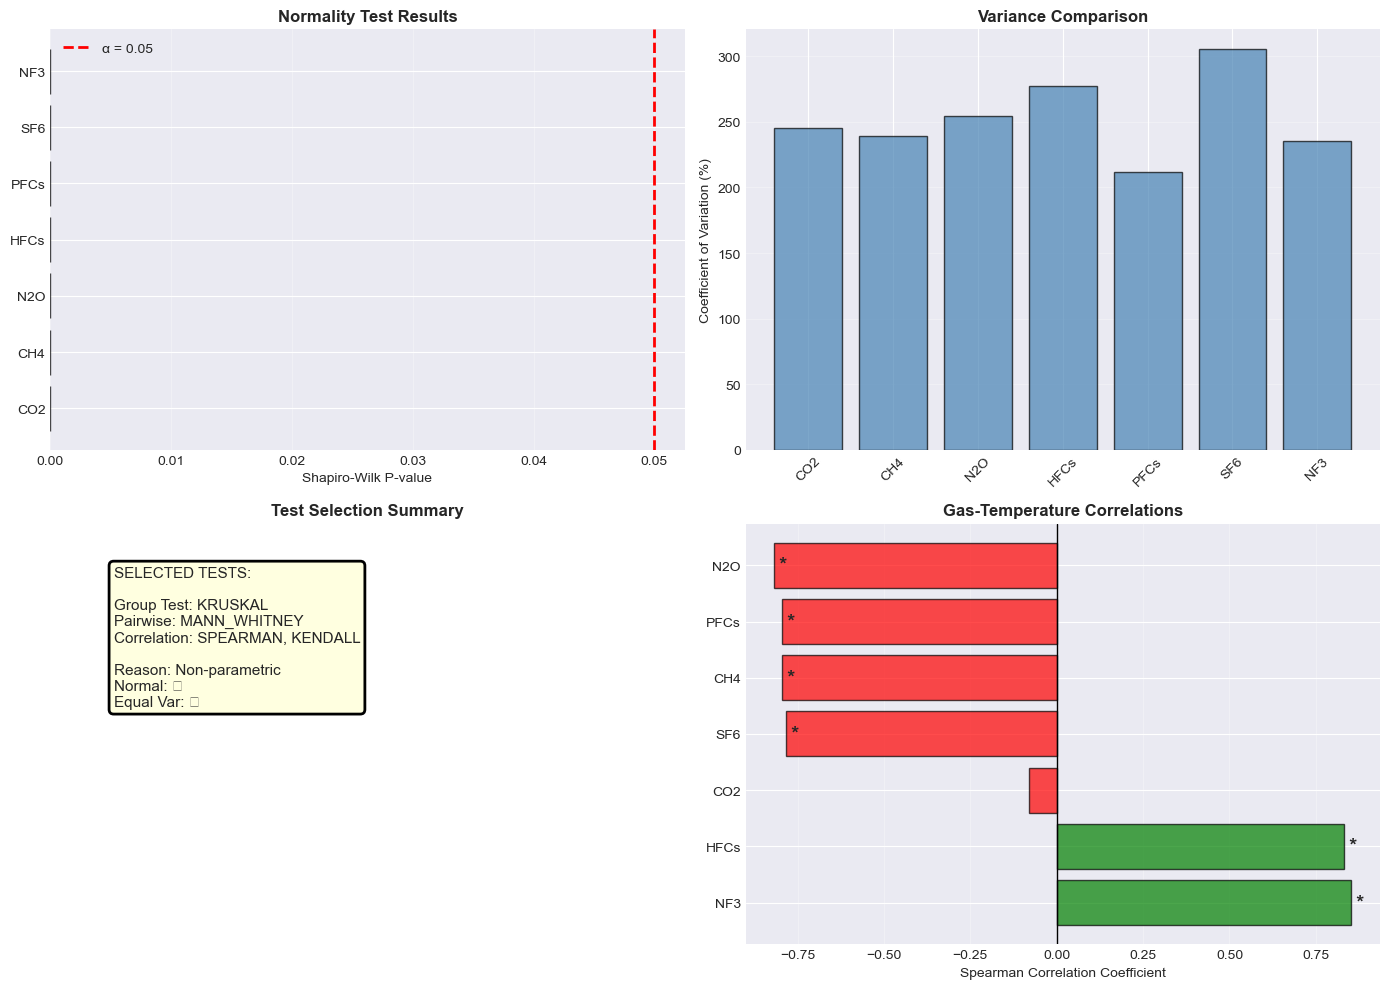


Figure: Comprehensive statistical test selection and results visualization
* indicates statistical significance (p < 0.05)


In [13]:
# Create summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Normality test results
if len(normality_df) > 0:
    colors = ['green' if x else 'red' for x in normality_df['Is_Normal']]
    axes[0, 0].barh(normality_df['Gas'], normality_df['Shapiro_p'], color=colors, alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
    axes[0, 0].set_xlabel('Shapiro-Wilk P-value')
    axes[0, 0].set_title('Normality Test Results', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3, axis='x')

# 2. Variance comparison
if len(variance_df) > 0:
    axes[0, 1].bar(variance_df['Gas'], variance_df['CV_%'], color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, 1].set_ylabel('Coefficient of Variation (%)')
    axes[0, 1].set_title('Variance Comparison', fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(alpha=0.3, axis='y')

# 3. Test selection summary
ax3 = axes[1, 0]
ax3.axis('off')
test_info = [
    f"Group Test: {test_recommendations['group_comparison'].upper()}",
    f"Pairwise: {test_recommendations['pairwise'].upper()}",
    f"Correlation: {', '.join([t.upper() for t in test_recommendations['correlation']])}",
    "",
    f"Reason: {'Parametric' if all_normal else 'Non-parametric'}",
    f"Normal: {'✓' if all_normal else '✗'}",
    f"Equal Var: {'✓' if equal_variances else '✗'}"
]
ax3.text(0.1, 0.9, 'SELECTED TESTS:\n\n' + '\n'.join(test_info),
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='black', linewidth=2))
ax3.set_title('Test Selection Summary', fontweight='bold')

# 4. Correlation results
if len(corr_df) > 0:
    colors = ['green' if c > 0 else 'red' for c in corr_df['Correlation']]
    bars = axes[1, 1].barh(range(len(corr_df)), corr_df['Correlation'], 
                           color=colors, alpha=0.7, edgecolor='black')
    axes[1, 1].set_yticks(range(len(corr_df)))
    axes[1, 1].set_yticklabels(corr_df['Gas'])
    axes[1, 1].set_xlabel(f'{test_type} Correlation Coefficient')
    axes[1, 1].set_title('Gas-Temperature Correlations', fontweight='bold')
    axes[1, 1].axvline(x=0, color='black', linewidth=1)
    axes[1, 1].grid(alpha=0.3, axis='x')
    
    # Add significance markers
    for i, (bar, sig) in enumerate(zip(bars, corr_df['Significant'])):
        if sig == 'Yes':
            axes[1, 1].text(bar.get_width(), i, ' *', ha='left', va='center', 
                           fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFigure: Comprehensive statistical test selection and results visualization")
print("* indicates statistical significance (p < 0.05)")

## 8. Export Results

In [14]:
# Export comprehensive results
print("\nExporting analysis results...")

# Export normality tests
if len(normality_df) > 0:
    normality_df.to_csv('normality_tests.csv', index=False)
    print("✓ Normality tests saved")

# Export variance analysis
if len(variance_df) > 0:
    variance_df.to_csv('variance_analysis.csv', index=False)
    print("✓ Variance analysis saved")

# Export test recommendations
recommendations_df = pd.DataFrame([
    {'Analysis_Type': 'Group Comparison', 'Recommended_Test': test_recommendations['group_comparison']},
    {'Analysis_Type': 'Pairwise Comparison', 'Recommended_Test': test_recommendations['pairwise']},
    {'Analysis_Type': 'Correlation', 'Recommended_Test': ', '.join(test_recommendations['correlation'])},
    {'Analysis_Type': 'Data_Normal', 'Recommended_Test': str(all_normal)},
    {'Analysis_Type': 'Equal_Variances', 'Recommended_Test': str(equal_variances)}
])
recommendations_df.to_csv('test_recommendations.csv', index=False)
print("✓ Test recommendations saved")

# Export correlation results
if len(corr_df) > 0:
    corr_df.to_csv('temperature_correlations.csv', index=False)
    print("✓ Temperature correlations saved")

print("✓ Dunn's test results (if applicable) saved")
print("\nAll exports completed successfully!")


Exporting analysis results...
✓ Normality tests saved
✓ Variance analysis saved
✓ Test recommendations saved
✓ Temperature correlations saved
✓ Dunn's test results (if applicable) saved

All exports completed successfully!


---

## Analysis Complete!

**This notebook demonstrates:**
1. ✓ Comprehensive assumption testing (normality, variance)
2. ✓ Intelligent test selection based on data properties
3. ✓ Justification for parametric vs non-parametric methods
4. ✓ Automated decision-making for appropriate statistical tests
5. ✓ Multiple correlation measures for robustness
6. ✓ Clear documentation of methodological choices

**Key Innovation:**
The analysis automatically selects appropriate statistical tests based on:
- Normality assessment results
- Variance homogeneity testing
- Sample size considerations
- Data distribution characteristics

This ensures **statistically valid conclusions** with **transparent methodology**.

---